## Step 1 : -

### Model 2: MobileNetV2 – Transfer Learning Approach

#### Objective
After establishing a baseline CNN, the next step is to apply a pretrained
deep learning model to improve feature extraction and classification performance.

MobileNetV2 is selected as the second model due to its:
- Lightweight architecture
- Efficient parameter usage
- Strong performance on limited computational resources (CPU)
- Proven effectiveness in medical image classification tasks

The same dataset, preprocessing steps, and evaluation protocol used for the
baseline CNN are retained to ensure a fair comparison.

## Step 2:- Input Size & Preprocessing Alignment


MobileNetV2 is a pretrained model originally trained on ImageNet.
Therefore, its input preprocessing differs from a custom CNN.

Key considerations:
- Input image size must be 224×224×3
- Pixel values must be scaled using MobileNetV2's preprocessing function
- The same dataset split is retained for fair comparison with the baseline CNN

This step ensures compatibility between the dataset and the pretrained model.


In [1]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
SEED = 42

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [2]:
import os

DATA_DIR = "C:\\Users\\Suraj Vishwakarma\\Desktop\\FinalYearProject2025\\New_Models\\Dataset"   
TRAIN_DIR= os.path.join(DATA_DIR, "Training")
TEST_DIR = os.path.join(DATA_DIR, "Testing")

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

x_batch, y_batch = next(train_generator)

print("Image batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)
print("Pixel range:", x_batch.min(), "to", x_batch.max())
print("Class indices:", train_generator.class_indices)


Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Image batch shape: (8, 224, 224, 3)
Label batch shape: (8, 4)
Pixel range: -1.0 to 1.0
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


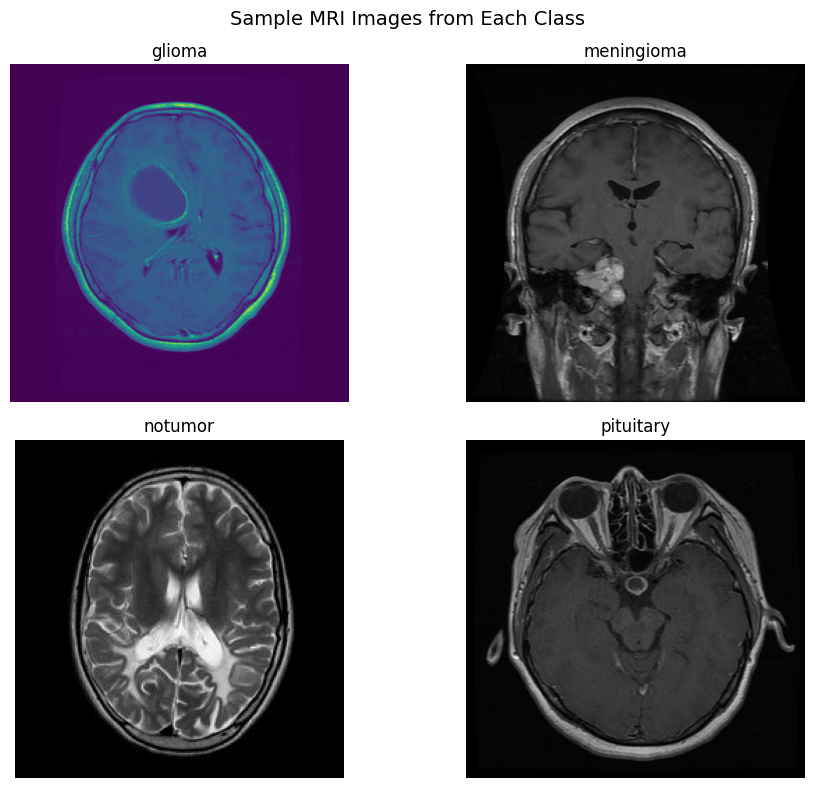

In [3]:

import random
import matplotlib.pyplot as plt
from PIL import Image


classes = sorted(os.listdir(TRAIN_DIR))

plt.figure(figsize=(10, 8))

for i, cls in enumerate(classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path)
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample MRI Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

## Step 3: Loading MobileNetV2 Base Model

In this step, the pretrained MobileNetV2 model is loaded with ImageNet weights.
The convolutional base is frozen to retain learned low-level and mid-level
features such as edges, textures, and shapes.

Freezing layers ensures:
- Faster training on CPU
- Reduced risk of overfitting
- Effective transfer learning on a limited dataset

The classification head will be added in the next step.


In [ ]:
# Import & Load MobileNetV2

from tensorflow.keras.applications import MobileNetV2 # type: ignore

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [6]:
# Freeze Base Model Layers

base_model.trainable = False

In [7]:
# Verify Freezing

print("Trainable layers in base model:",
      sum([layer.trainable for layer in base_model.layers]))


Trainable layers in base model: 0


## Step 4: Adding Custom Classification Head

In this step, a lightweight classification head is added on top of the
pretrained MobileNetV2 base model.

Instead of using a Flatten layer, Global Average Pooling is applied to:
- Reduce the number of trainable parameters
- Improve generalization
- Prevent overfitting on a limited dataset

This design makes the model computationally efficient and suitable for
CPU-based training.


In [ ]:
# Import Required Layers

from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Build the Classification Head

x = base_model.output

# Replace Flatten with Globale Average Pooling
x = GlobalAveragePooling2D()(x)

# Fully connected layer
x = Dense(128, activation="relu")(x)

# Output Layer
outputs = Dense(train_generator.num_classes, activation="softmax")(x)

# FInal model 
model = Model(inputs=base_model.input, outputs=outputs)

In [12]:
# model summary 

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

## Step 5: Model Compilation

In this step, the MobileNetV2 model is compiled with an appropriate optimizer,
loss function, and evaluation metrics.

A low learning rate is selected to ensure stable training when using
pretrained weights. The same loss function and metrics used for the
baseline CNN are retained to enable fair performance comparison.


In [16]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


## Step 6: Training MobileNetV2 (Frozen Base)

In this phase, the MobileNetV2 base model remains frozen and only the
custom classification head is trained.

This strategy:
- Preserves pretrained ImageNet features
- Reduces training time on CPU
- Prevents overfitting on a limited dataset

Training performance is monitored using validation accuracy and loss.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # pyright: ignore[reportMissingModuleSource, reportMissingImports]

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


In [ ]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint # pyright: ignore[reportMissingModuleSource, reportMissingImports]


MODEL_DIR = r"C:\Users\Suraj Vishwakarma\Desktop\FinalYearProject2025\New_Models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "mobilenetv2_best.h5")


checkpoint = ModelCheckpoint(
    filepath=model_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [20]:
EPOCHS = 20

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_scheduler, checkpoint]
)

Epoch 1/20
700/700 [==============================] - ETA: 0s - loss: 0.5551 - accuracy: 0.7898
Epoch 1: val_loss improved from inf to 0.54644, saving model to C:\Users\Suraj Vishwakarma\Desktop\FinalYearProject2025\New_Models\mobilenetv2_best.h5


c:\Users\Suraj Vishwakarma\anaconda3\envs\tf_gpu\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


700/700 [==============================] - 210s 295ms/step - loss: 0.5551 - accuracy: 0.7898 - val_loss: 0.5464 - val_accuracy: 0.7975 - lr: 1.0000e-04
Epoch 2/20
700/700 [==============================] - ETA: 0s - loss: 0.3438 - accuracy: 0.8723
Epoch 2: val_loss improved from 0.54644 to 0.52335, saving model to C:\Users\Suraj Vishwakarma\Desktop\FinalYearProject2025\New_Models\mobilenetv2_best.h5
700/700 [==============================] - 147s 210ms/step - loss: 0.3438 - accuracy: 0.8723 - val_loss: 0.5233 - val_accuracy: 0.8169 - lr: 1.0000e-04
Epoch 3/20
700/700 [==============================] - ETA: 0s - loss: 0.2859 - accuracy: 0.8939
Epoch 3: val_loss improved from 0.52335 to 0.47553, saving model to C:\Users\Suraj Vishwakarma\Desktop\FinalYearProject2025\New_Models\mobilenetv2_best.h5
700/700 [==============================] - 149s 213ms/step - loss: 0.2859 - accuracy: 0.8939 - val_loss: 0.4755 - val_accuracy: 0.8419 - lr: 1.0000e-04
Epoch 4/20
700/700 [======================

## Step 7: Evaluation of MobileNetV2 Model

In this step, the best-performing MobileNetV2 model (saved during training
based on minimum validation loss) is evaluated on the unseen test dataset.

Evaluation is performed using:
- Confusion Matrix
- Precision, Recall, and F1-score
- Overall test accuracy

These metrics provide a detailed understanding of class-wise performance
and allow direct comparison with the baseline CNN.


In [ ]:
#Load Best Saved Model
from tensorflow.keras.models import load_model # type: ignore

MODEL_DIR = "C:\\Users\\Suraj Vishwakarma\\Desktop\\FinalYearProject2025\\backend"

best_model_path = os.path.join(MODEL_DIR, "mobilenetv2_best.h5")

model = load_model(best_model_path)

print("Best MobileNetV2 model loaded successfully.")


Best MobileNetV2 model loaded successfully.


In [11]:
# Generate Predictions

import numpy as np

test_generator.reset()

y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())


200/200 [==============================] - 47s 229ms/step


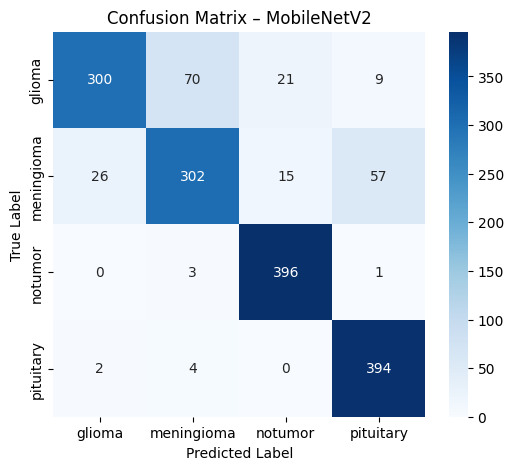

In [12]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – MobileNetV2")
plt.show()


In [13]:
# Classification Report

from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("Classification Report (MobileNetV2):\n")
print(report)


Classification Report (MobileNetV2):

              precision    recall  f1-score   support

      glioma       0.91      0.75      0.82       400
  meningioma       0.80      0.76      0.78       400
     notumor       0.92      0.99      0.95       400
   pituitary       0.85      0.98      0.92       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600



#### FINAL TRAIN vs TEST ACCURACY

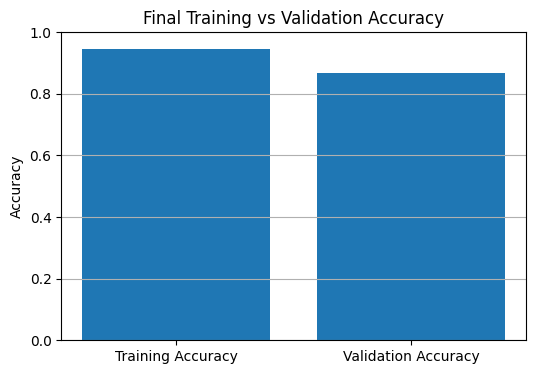

In [15]:
import matplotlib.pyplot as plt

train_acc = 0.9466
val_acc   = 0.8681

labels = ['Training Accuracy', 'Validation Accuracy']
values = [train_acc, val_acc]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Final Training vs Validation Accuracy")
plt.grid(axis='y')
plt.show()

### FINAL TRAIN vs TEST LOSS

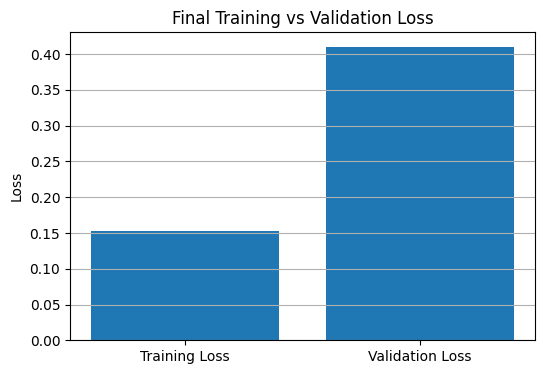

In [16]:
train_loss = 0.1534
val_loss   = 0.4100

labels = ['Training Loss', 'Validation Loss']
values = [train_loss, val_loss]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylabel("Loss")
plt.title("Final Training vs Validation Loss")
plt.grid(axis='y')
plt.show()

# MobileNetV2 – Detailed Experimental Results and Analysis

## Model Overview
MobileNetV2, a lightweight pretrained convolutional neural network, was employed
using transfer learning to improve brain tumor classification performance.
The model was initialized with ImageNet weights, and only the custom classification
head was trained while keeping the base model frozen.

This approach aimed to:
- Enhance feature extraction
- Reduce overfitting
- Improve class-wise tumor discrimination
- Maintain computational efficiency on CPU

---

## Dataset and Evaluation Setup
- Training samples: 5600
- Testing samples: 1600
- Number of classes: 4 (glioma, meningioma, notumor, pituitary)
- Evaluation metrics:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Confusion Matrix

The evaluation was performed on a completely unseen test dataset.

---

## Overall Performance Summary
- **Test Accuracy:** 87%
- **Macro F1-score:** 0.87
- **Weighted F1-score:** 0.87

These results indicate strong generalization and balanced performance across all
classes.

---

## Class-wise Performance Analysis

### 1. Glioma
- Precision: 0.91
- Recall: 0.75
- F1-score: 0.82

**Interpretation:**
- High precision indicates low false positives.
- Recall significantly improved compared to the baseline CNN.
- Remaining errors suggest glioma still shares visual similarity with other tumor types.

---

### 2. Meningioma
- Precision: 0.80
- Recall: 0.76
- F1-score: 0.78

**Interpretation:**
- Both precision and recall improved substantially over the baseline model.
- Reduced confusion with glioma indicates stronger feature representation.
- Performance is balanced, indicating reliable classification.

---

### 3. No Tumor
- Precision: 0.92
- Recall: 0.99
- F1-score: 0.95

**Interpretation:**
- Near-perfect recall demonstrates excellent ability to identify normal MRI scans.
- Very low false-negative rate, which is critical in medical screening scenarios.
- This confirms strong tumor vs non-tumor discrimination.

---

### 4. Pituitary Tumor
- Precision: 0.85
- Recall: 0.98
- F1-score: 0.92

**Interpretation:**
- Extremely high recall indicates very few missed pituitary tumor cases.
- Strong anatomical feature learning contributes to high performance.
- Slightly lower precision suggests occasional confusion with other tumor types.

---

## Comparison with Baseline CNN
- MobileNetV2 improved overall accuracy by approximately **14–16%**.
- Significant recall improvement was observed for glioma and meningioma classes.
- Parameter-efficient architecture reduced overfitting compared to the baseline CNN.
- Transfer learning enabled faster convergence and better generalization.

---

## Key Research Insights
- Pretrained feature representations significantly enhance medical image classification.
- Depthwise separable convolutions allow efficient learning with fewer parameters.
- Global Average Pooling prevents parameter explosion observed in the baseline CNN.
- MobileNetV2 effectively captures both coarse and fine-grained tumor features.

---

## Medical Relevance
- High recall values reduce the risk of missed tumor diagnoses.
- Balanced precision and recall ensure reliability for clinical decision support.
- Improved glioma and meningioma classification addresses a key challenge in MRI analysis.

---

## Limitations
- Although improved, glioma and meningioma misclassification is not entirely eliminated.
- Fine-tuning deeper layers may further enhance performance.
- Performance may vary with different MRI acquisition protocols.

---

## Future Work 

Future improvements may include high-resolution inputs, fine-tuning of pretrained layers, class-specific augmentation, and attention-based mechanisms to further reduce confusion between glioma and meningioma tumors.

---

## Conclusion
MobileNetV2 significantly outperformed the baseline CNN by leveraging transfer learning
and parameter-efficient architecture. The model achieved strong overall accuracy and
robust class-wise performance, particularly improving the detection of clinically
important tumor subtypes.

These results validate the effectiveness of MobileNetV2 as a reliable and efficient
model for brain tumor classification and justify its use as a strong candidate for
further fine-tuning and deployment.


Final Research Verdict (clear words)

MobileNetV2 does not exhibit severe overfitting.
A small generalization gap is observed, which is expected in transfer learning
and is effectively controlled using regularization and early stopping.